## Document Forgery Detection: Machine Learning Classification Report

### Overview

This notebook trains and evaluates a Random Forest model for forged-document detection using features produced by `forged_document_detector.py`.
The report emphasizes stakeholder-ready evidence for banking use cases:
- **Accuracy and class-level quality** (precision, recall, F1-score)
- **Confusion matrix** on on both hold-out and generated train/validation/testing data
- **Risk-oriented metrics** like false positive/negative rates
- **Model explainability** via top forensic indicators


In [18]:
import json
import os
from pathlib import Path
import joblib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    matthews_corrcoef,
    precision_recall_fscore_support,
    roc_auc_score,
)

from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")


In [19]:
# Load datasets generated from `training_set` / `validation_set` / `testing_set`
TRAIN_DATASET_PATH = "ml_training_data.csv"
VALIDATION_DATASET_PATH = "ml_validation_data.csv"
TEST_DATASET_PATH = "ml_test_data.csv"

if not Path(TRAIN_DATASET_PATH).exists():
    raise FileNotFoundError(f"Missing required dataset: {TRAIN_DATASET_PATH}")

df_train_raw = pd.read_csv(TRAIN_DATASET_PATH)
print("Training dataset shape:", df_train_raw.shape)
display(df_train_raw.head())

print("Training label distribution:")
print(df_train_raw["Label"].value_counts())
assert df_train_raw["Label"].nunique() == 2, (
    "Dataset contains only one class; forgery detection requires genuine + forged examples."
)
if Path(VALIDATION_DATASET_PATH).exists():
    df_validation = pd.read_csv(VALIDATION_DATASET_PATH)
    print("Validation dataset shape:", df_validation.shape)
    print("Validation label distribution:")
    print(df_validation["Label"].value_counts())
else:
    df_validation = None
    print("No ml_validation_data.csv found. Validation-set evaluation will be skipped.")

if Path(TEST_DATASET_PATH).exists():
    df_test = pd.read_csv(TEST_DATASET_PATH)
    print("Test dataset shape:", df_test.shape)
    print("Test label distribution:")
    print(df_test["Label"].value_counts())
else:
    df_test = None
    print("No ml_test_data.csv found. Testing-set evaluation will be skipped.")


Training dataset shape: (465, 24)


,Document_ID,Label,Country_Code,Char_Count,NER_Detected_Count,NER_Completeness_Ratio,H_Mean,H_STD,W_Mean,W_STD,...,Grad_Mean,Grad_STD,Ink_Density_Mean,Geo_Anomaly_Ratio,Ink_Anomaly_Ratio,BG_Mean,BG_STD,OCR_Box_Anomalies_Count,BG_Anomaly_Line_Count,Clustered_Regions_Count
0,alb_id_00.jpg,0,ALB,1031,0,0.0,14.871969,18.104747,10.681862,16.236242,...,1081.513725,805.213918,0.395999,0.088264,0.029098,201.798470,21.507284,3,0,135
1,alb_id_00_fake_6_25.jpg,1,ALB,926,0,0.0,15.379050,19.206223,11.402808,17.750270,...,1052.257494,847.928616,0.400173,0.091793,0.031317,201.770948,21.277130,2,0,126
2,alb_id_01.jpg,0,ALB,1058,0,0.0,15.126654,18.177476,10.912098,16.734184,...,1076.812163,804.949704,0.395686,0.095463,0.025520,201.710142,21.788141,3,0,146
3,alb_id_01_fake_6_56.jpg,1,ALB,1063,0,0.0,15.146754,18.255094,10.976482,16.199846,...,1059.275508,809.192322,0.393883,0.089370,0.027281,201.669039,21.578188,3,0,144
4,alb_id_01_fake_6_61.jpg,1,ALB,1137,0,0.0,14.646438,16.848277,10.488127,14.759523,...,1056.630225,783.919841,0.392323,0.087071,0.025506,201.589883,21.536542,3,0,163


Training label distribution:
Label
1    253
0    212
Name: count, dtype: int64
Validation dataset shape: (99, 24)
Validation label distribution:
Label
1    51
0    48
Name: count, dtype: int64
Test dataset shape: (101, 24)
Test label distribution:
Label
1    61
0    40
Name: count, dtype: int64


In [20]:
# Feature / Target Split + categorical encoding
DROP_COLUMNS = ["Document_ID", "Label"]
X_raw = df_train_raw.drop(columns=DROP_COLUMNS, errors="ignore")
y = df_train_raw["Label"].astype(int)

# Handle non-numeric features (e.g., Country_Code='LVA')
categorical_cols = X_raw.select_dtypes(include=["object", "category"]).columns.tolist()
print("Categorical columns detected:", categorical_cols if categorical_cols else "None")
X = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=False)
print("Encoded feature count:", X.shape[1])
print("Sample encoded feature columns:", X.columns[:10].tolist())


Categorical columns detected: ['Country_Code']
Encoded feature count: 24
Sample encoded feature columns: ['Char_Count', 'NER_Detected_Count', 'NER_Completeness_Ratio', 'H_Mean', 'H_STD', 'W_Mean', 'W_STD', 'AR_Mean', 'AR_STD', 'Ink_Mean']


### Train/Test Split (70:30 Ratio)

In [21]:
# 70:30 hold-out split for unbiased validation
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 325
Testing samples: 140


### Baseline Model

In [22]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

dummy_preds = dummy.predict(X_test)

print("=== BASELINE (Most Frequent Class) ===")
print(f"Accuracy: {accuracy_score(y_test, dummy_preds):.4f}")
print(classification_report(y_test, dummy_preds, target_names=["Genuine", "Forged"], zero_division=0))


=== BASELINE (Most Frequent Class) ===
Accuracy: 0.5429
              precision    recall  f1-score   support

     Genuine       0.00      0.00      0.00        64
      Forged       0.54      1.00      0.70        76

    accuracy                           0.54       140
   macro avg       0.27      0.50      0.35       140
weighted avg       0.29      0.54      0.38       140



### Random Forest Classifier Training

In [23]:
# Train Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=350,
    max_depth=12,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
)
rf_model.fit(X_train, y_train)
print("Random Forest training complete.")



Random Forest training complete.


In [24]:
from sklearn import metrics


def evaluate_classifier(model, X_eval, y_eval, dataset_name="Dataset"):
    preds = model.predict(X_eval)
    probs = model.predict_proba(X_eval)[:, 1] if hasattr(model, "predict_proba") else None

    precision, recall, f1, _ = precision_recall_fscore_support(
       y_eval, 
       preds, 
       average='binary', 
       zero_division=0,
       )  
      
    metrics = {
        "dataset": dataset_name,
        "accuracy": float(accuracy_score(y_eval, preds)),
        "balanced_accuracy": float(balanced_accuracy_score(y_eval, preds)),
        "precision" : float(precision),
        "recall": float(recall),
        "f1_score": float(f1),
        "mcc": float(matthews_corrcoef(y_eval, preds)),
        "roc_auc": float(roc_auc_score(y_eval, probs)) if probs is not None else None,
        "classification_report" : classification_report(
            y_eval, 
            preds, 
            target_names=["Genuine", "Forged"],
            output_dict=True,
            zero_division=0,
            )
     }
        
    tn, fp, fn, tp = confusion_matrix(y_eval, preds).ravel()
    metrics.update(
        {
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
            "false_positive_rate": float(fp / (fp + tn)) if (fp + tn) > 0 else 0.0,
            "false_negative_rate": float(fn / (fn + tp)) if (fn + tp) > 0 else 0.0,
        }
    )

    print(f"=== RANDOM FOREST RESULTS ({dataset_name}) ===")
    print(f"Accuracy:           {metrics['accuracy']:.4f}")
    print(f"Balanced Accuracy:  {metrics['balanced_accuracy']:.4f}")
    print(f"Precision:          {metrics['precision']:.4f}")
    print(f"Recall:             {metrics['recall']:.4f}")
    print(f"F1-Score:           {metrics['f1_score']:.4f}")
    print(f"MCC:                {metrics['mcc']:.4f}")
    if metrics["roc_auc"] is not None:
        print(f"ROC AUC:        {metrics['roc_auc']:.4f}")
    print(f"FPR / FNR:         {metrics['false_positive_rate']:.4f} / {metrics['false_negative_rate']:.4f}")
    print(f"Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(classification_report(y_eval, preds, target_names=["Genuine", "Forged"], zero_division=0))

    return preds, metrics

y_pred_holdout, holdout_metrics = evaluate_classifier(rf_model, X_test, y_test, dataset_name="Hold-out Test")

    

=== RANDOM FOREST RESULTS (Hold-out Test) ===
Accuracy:           0.7214
Balanced Accuracy:  0.7113
Precision:          0.7079
Recall:             0.8289
F1-Score:           0.7636
MCC:                0.4376
ROC AUC:        0.7827
FPR / FNR:         0.4062 / 0.1711
Confusion Matrix: TN=38, FP=26, FN=13, TP=63
              precision    recall  f1-score   support

     Genuine       0.75      0.59      0.66        64
      Forged       0.71      0.83      0.76        76

    accuracy                           0.72       140
   macro avg       0.73      0.71      0.71       140
weighted avg       0.72      0.72      0.72       140



#### Save the Trained Model

This avoids having to retrain the model every time you want to make a prediction.

In [25]:
MODEL_DIR = "trained_models"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, "forged_document_rf_model.pkl")
joblib.dump(rf_model, model_path)
print(f"Trained model saved to: {model_path}")

Trained model saved to: trained_models\forged_document_rf_model.pkl


In [26]:
# Save feature column order for consistent inference
feature_columns_path = os.path.join(MODEL_DIR, "feature_columns.pkl")
joblib.dump(list(X.columns), feature_columns_path)

print(f"Feature column order saved to: {feature_columns_path}")
metrics_path = os.path.join(MODEL_DIR, "training_metrics.json")
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(holdout_metrics, f, indent=2)
print(f"Hold-out metrics saved to: {metrics_path}")

Feature column order saved to: trained_models\feature_columns.pkl
Hold-out metrics saved to: trained_models\training_metrics.json


### Key Results and Risk Signals for Banking Stakeholders

The next sections provide model evidence relevant to financial institutions:
- How many genuine documents may be wrongly blocked (**False Positives**)
- How many forged documents may pass undetected (**False Negatives**)
- Which forensic signals contribute most to automated screening decisions

### Confusion Matrix (Hold-out Test Set)

The Confusion Matrix visually represents the model's performance on the testing set, detailing true positives, true negatives, and classification errors.

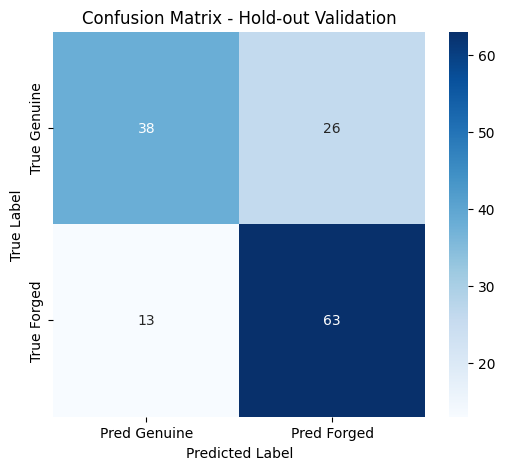

In [27]:
cm = confusion_matrix(y_test, y_pred_holdout)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Genuine", "Pred Forged"],
    yticklabels=["True Genuine", "True Forged"],
)
plt.title("Confusion Matrix - Hold-out Validation")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


=== RANDOM FOREST RESULTS (Validation Set) ===
Accuracy:           0.6768
Balanced Accuracy:  0.6759
Precision:          0.6792
Recall:             0.7059
F1-Score:           0.6923
MCC:                0.3524
ROC AUC:        0.7806
FPR / FNR:         0.3542 / 0.2941
Confusion Matrix: TN=31, FP=17, FN=15, TP=36
              precision    recall  f1-score   support

     Genuine       0.67      0.65      0.66        48
      Forged       0.68      0.71      0.69        51

    accuracy                           0.68        99
   macro avg       0.68      0.68      0.68        99
weighted avg       0.68      0.68      0.68        99



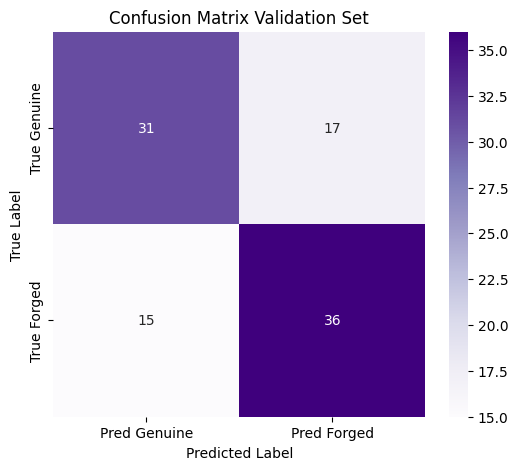

=== RANDOM FOREST RESULTS (Test Set) ===
Accuracy:           0.8416
Balanced Accuracy:  0.8215
Precision:          0.8358
Recall:             0.9180
F1-Score:           0.8750
MCC:                0.6655
ROC AUC:        0.9000
FPR / FNR:         0.2750 / 0.0820
Confusion Matrix: TN=29, FP=11, FN=5, TP=56
              precision    recall  f1-score   support

     Genuine       0.85      0.72      0.78        40
      Forged       0.84      0.92      0.88        61

    accuracy                           0.84       101
   macro avg       0.84      0.82      0.83       101
weighted avg       0.84      0.84      0.84       101



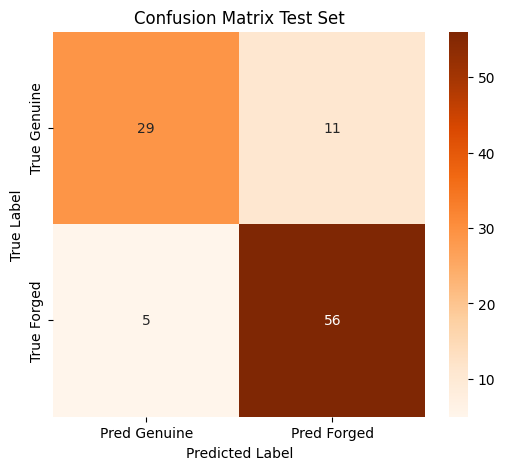

Updated metrics saved to: trained_models\training_metrics.json


In [28]:
# Evaluation on input_docs-derived dataset (ml_test_data.csv)
validation_metrics = None
testing_metrics = None

def evaluate_external_dataset(df_external, dataset_name, cmap):
    X_external_raw = df_external.drop(columns=DROP_COLUMNS, errors="ignore")
    y_external = df_external["Label"].astype(int)
    X_external = pd.get_dummies(X_external_raw, columns=categorical_cols, drop_first=False)
    X_external = X_external.reindex(columns=X.columns, fill_value=0)
    y_pred_external, metrics_external = evaluate_classifier(
        rf_model,
        X_external,
        y_external,
        dataset_name=dataset_name,
    )

    cm_external = confusion_matrix(y_external, y_pred_external)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm_external,
        annot=True,
        fmt="d",
        cmap=cmap,
        xticklabels=["Pred Genuine", "Pred Forged"],
        yticklabels=["True Genuine", "True Forged"],
    )
    plt.title(f"Confusion Matrix {dataset_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    return metrics_external

if df_validation is not None:
    validation_metrics = evaluate_external_dataset(df_validation, "Validation Set", cmap="Purples")
else:
    print("Validation-set evaluation skipped (ml_validation_data.csv not found.")

if df_test is not None:
    testing_metrics = evaluate_external_dataset(df_test, "Test Set", cmap="Oranges")
else:
    print("Test-set evaluation skipped (ml_test_data.csv not found.")

payload = {"holdout": holdout_metrics}
if validation_metrics is not None:
    payload["validation_set"] = validation_metrics
if testing_metrics is not None:
    payload["testing_set"] = testing_metrics 

with open(metrics_path, "w", encoding="utf-8") as f: 
      json.dump(payload, f, indent=2)

print(f"Updated metrics saved to: {metrics_path}")


#### Feature Importance

This chart highlights the most influential forensic features used by the Random Forest model. These indicators can guide compliance teams when prioritizing manual review and fraud controls.

In [29]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(15)


W_Mean                     0.114192
AR_Mean                    0.082027
Geo_Anomaly_Ratio          0.074286
W_STD                      0.071095
Ink_Density_Mean           0.064294
H_Mean                     0.058955
Char_Count                 0.058030
BG_STD                     0.054900
AR_STD                     0.054573
H_STD                      0.054154
Grad_STD                   0.048146
Grad_Mean                  0.047057
Ink_Anomaly_Ratio          0.043889
Clustered_Regions_Count    0.043091
Ink_Mean                   0.042456
dtype: float64

In [30]:
results = X_test.copy()
results["True_Label"] = y_test.values
results["Predicted_Label"] = y_pred_holdout

errors = results[results["True_Label"] != results["Predicted_Label"]]
print("Misclassified hold-out samples:", len(errors))

errors.head()


Misclassified hold-out samples: 39


,Char_Count,NER_Detected_Count,NER_Completeness_Ratio,H_Mean,H_STD,W_Mean,W_STD,AR_Mean,AR_STD,Ink_Mean,...,BG_Mean,BG_STD,OCR_Box_Anomalies_Count,BG_Anomaly_Line_Count,Clustered_Regions_Count,Country_Code_ALB,Country_Code_LVA,Country_Code_SVK,True_Label,Predicted_Label
73,1029,0,0.0,14.247813,15.841655,9.734694,14.327035,0.697390,0.419095,201.297301,...,201.089671,22.647744,3,0,155,True,False,False,1,0
297,417,0,0.0,19.678657,16.900253,23.105516,36.461581,1.133186,0.882855,153.809338,...,227.829134,21.182740,2,0,53,False,True,False,1,0
159,391,0,0.0,21.035806,17.027396,24.434783,38.507716,1.128381,1.043575,147.801341,...,227.049441,22.086064,2,0,52,False,True,False,0,1
280,411,0,0.0,19.087591,15.382143,21.175182,31.489441,1.117048,0.969400,154.948510,...,228.014468,20.466687,2,0,56,False,True,False,0,1
203,395,0,0.0,19.979747,16.746648,22.440506,32.945577,1.134946,0.888278,152.550533,...,227.888341,21.238367,2,0,55,False,True,False,0,1


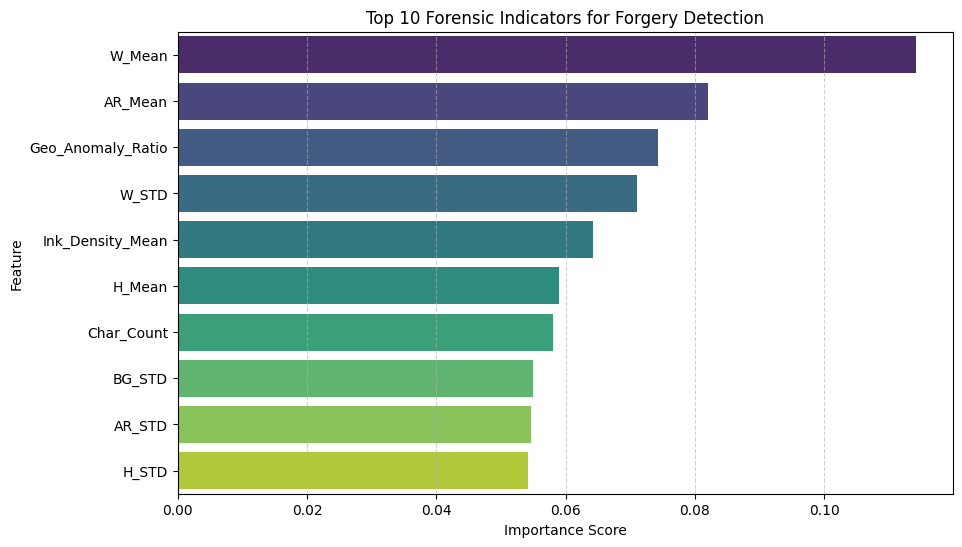

In [31]:
# Top 10 forensic indicator
top_features = importances.nlargest(10)
plt.figure(figsize=(10, 6))
top_features = importances.nlargest(10)
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title('Top 10 Forensic Indicators for Forgery Detection')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [32]:
# Executive-ready summary table
summary_rows = [
  {
    "Dataset": "Hold-out Test",
    "Accuracy": holdout_metrics["accuracy"],
    "Balanced Accuracy": holdout_metrics["balanced_accuracy"],
    "Precision": holdout_metrics["precision"],
    "Recall": holdout_metrics["recall"],
    "F1-Score": holdout_metrics["f1_score"],
    "False Positive Rate": holdout_metrics["false_positive_rate"],
    "False Negative Rate": holdout_metrics["false_negative_rate"],
  }
]

if validation_metrics is not None:
    summary_rows.append(
        {
            "Dataset": "Validation Set",
            "Accuracy": validation_metrics["accuracy"],
            "Balanced Accuracy": validation_metrics["balanced_accuracy"],
            "Precision": validation_metrics["precision"],
            "Recall": validation_metrics["recall"],
            "F1-Score": validation_metrics["f1_score"],
            "False Positive Rate": validation_metrics["false_positive_rate"],
            "False Negative Rate": validation_metrics["false_negative_rate"],
        }
    )

if testing_metrics  is not None:
    summary_rows.append(
        {
            "Dataset": "Testing Set",
            "Accuracy": testing_metrics["accuracy"],
            "Balanced Accuracy": testing_metrics["balanced_accuracy"],
            "Precision": testing_metrics["precision"],
            "Recall": testing_metrics["recall"],
            "F1-Score": testing_metrics["f1_score"],
            "False Positive Rate": testing_metrics["false_positive_rate"],
            "False Negative Rate": testing_metrics["false_negative_rate"],
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df.style.format({
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "False Positive Rate": "{:.4f}",
        "False Negative Rate": "{:.4f}",
})

    


,Dataset,Accuracy,Balanced Accuracy,Precision,Recall,F1-Score,False Positive Rate,False Negative Rate
0,Hold-out Test,0.7214,0.7113,0.7079,0.8289,0.7636,0.4062,0.1711
1,Validation Set,0.6768,0.6759,0.6792,0.7059,0.6923,0.3542,0.2941
2,Testing Set,0.8416,0.8215,0.8358,0.9180,0.8750,0.2750,0.0820
